# Visualizations
## Al-Rajab Lenders — Borrower Default Risk Analysis

Three supporting charts summarizing the key findings and model behavior from this project:
1. Default rate by prior severe late-payment history
2. Default rate by age group
3. Recall/Precision trade-off across decision thresholds


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, precision_score, accuracy_score

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('credit_risk_cleaned.csv')
print(f"Dataset shape: {df.shape}")


Dataset shape: (149999, 12)


## Chart 1: Default Rate by Prior Severe Late-Payment History

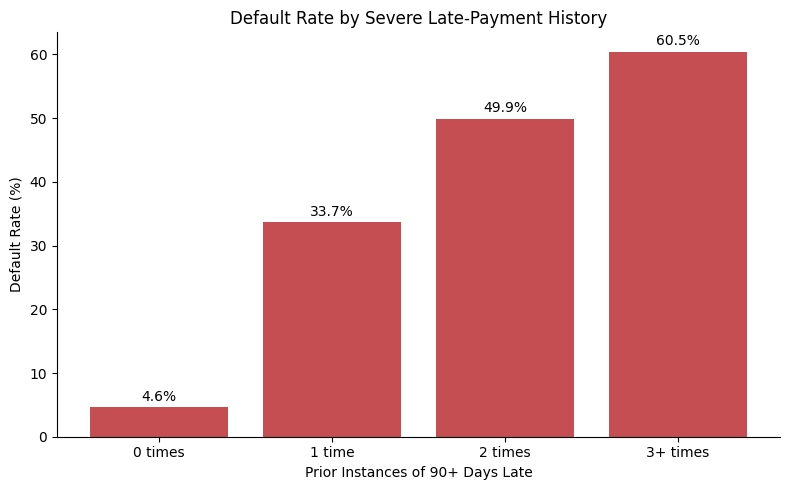

In [2]:
def bucket_late(x):
    if x == 0: return '0 times'
    elif x == 1: return '1 time'
    elif x == 2: return '2 times'
    else: return '3+ times'

df['late_90_bucket'] = df['NumberOfTimes90DaysLate'].apply(bucket_late)
order = ['0 times', '1 time', '2 times', '3+ times']

result = df.groupby('late_90_bucket')['SeriousDlqin2yrs'].mean().reindex(order) * 100

fig, ax = plt.subplots()
bars = ax.bar(result.index, result.values, color='#C44E52')
ax.set_ylabel('Default Rate (%)')
ax.set_xlabel('Prior Instances of 90+ Days Late')
ax.set_title('Default Rate by Severe Late-Payment History')
for bar, val in zip(bars, result.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%',
            ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('chart_late_payment_history.png', dpi=150)
plt.show()


## Chart 2: Default Rate by Age Group

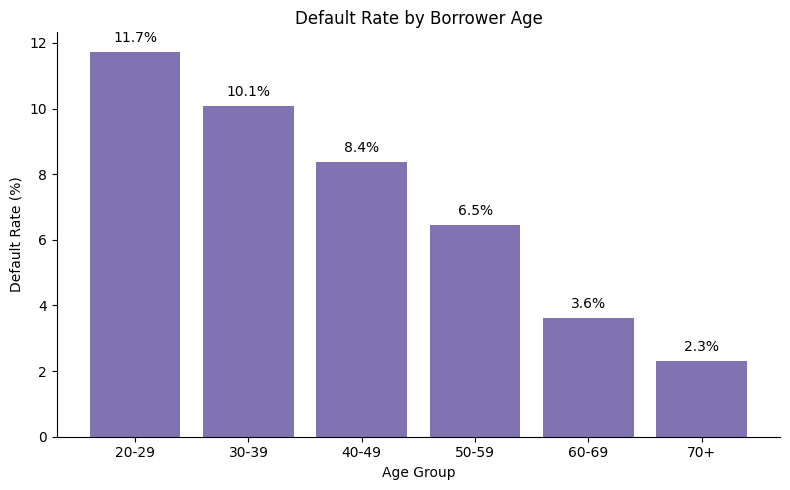

In [3]:
def bucket_age(x):
    if x < 30: return '20-29'
    elif x < 40: return '30-39'
    elif x < 50: return '40-49'
    elif x < 60: return '50-59'
    elif x < 70: return '60-69'
    else: return '70+'

df['age_bucket'] = df['age'].apply(bucket_age)
age_order = ['20-29','30-39','40-49','50-59','60-69','70+']

age_result = df.groupby('age_bucket')['SeriousDlqin2yrs'].mean().reindex(age_order) * 100

fig, ax = plt.subplots()
bars = ax.bar(age_result.index, age_result.values, color='#8172B2')
ax.set_ylabel('Default Rate (%)')
ax.set_xlabel('Age Group')
ax.set_title('Default Rate by Borrower Age')
for bar, val in zip(bars, age_result.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%',
            ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('chart_age.png', dpi=150)
plt.show()


## Chart 3: Recall/Precision Trade-off Across Decision Thresholds

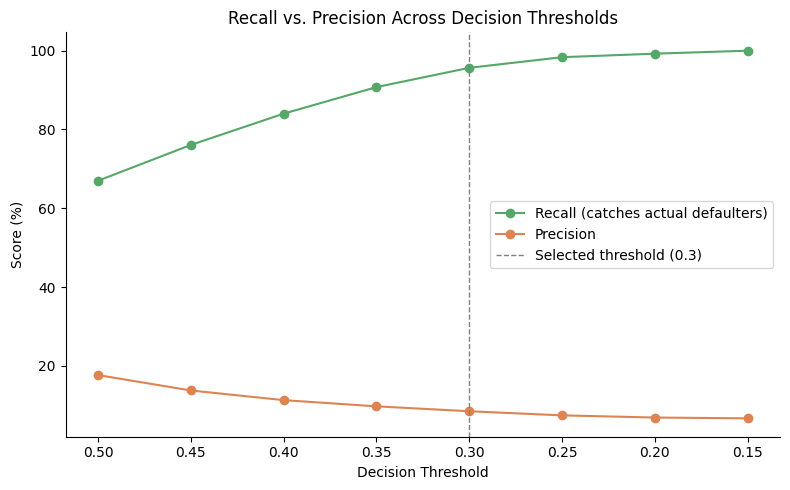

In [4]:
X = df.drop(columns=['SeriousDlqin2yrs', 'late_90_bucket', 'age_bucket'])
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)
y_probs = model.predict_proba(X_test_scaled)[:, 1]

thresholds = [0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15]
recalls, precisions = [], []
for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    recalls.append(recall_score(y_test, y_pred_t) * 100)
    precisions.append(precision_score(y_test, y_pred_t) * 100)

fig, ax = plt.subplots()
ax.plot(thresholds, recalls, marker='o', label='Recall (catches actual defaulters)', color='#55A868')
ax.plot(thresholds, precisions, marker='o', label='Precision', color='#DD8452')
ax.axvline(0.3, color='gray', linestyle='--', linewidth=1, label='Selected threshold (0.3)')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score (%)')
ax.set_title('Recall vs. Precision Across Decision Thresholds')
ax.invert_xaxis()
ax.legend()
plt.tight_layout()
plt.savefig('chart_threshold_tradeoff.png', dpi=150)
plt.show()


## Summary

These three charts visually confirm the project's key findings: severe late-payment history is a
dramatic, step-wise predictor of default risk; age shows a steady inverse relationship with
default risk; and the recall/precision trade-off chart shows why threshold 0.3 was selected as a
practical balance, rather than the default 0.5 or an extreme setting that would reject nearly all
applicants.
